# 📊 E-Commerce Customer Segmentation & Behavior Analysis

**Objective:** Segment 6,000 e-commerce customers using RFM (Recency, Frequency, Monetary) analysis to identify high-value customers, detect churn risk, and generate actionable retention strategies.

**Dataset:** ~67,700 synthetic transactions across 5 product categories (2022–2024)

**Key Finding:** The top 20% of customers generate ~65% of total revenue - a clear validation of the Pareto Principle that should guide marketing spend prioritisation.


## 1. Setup & Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

print("✅ Libraries imported successfully!")
print(f"Analysis Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

✅ Libraries imported successfully!
Analysis Date: 2026-02-01 03:46:13


## 2. Data Loading & Exploration

We start by loading the transaction dataset and getting an overview of its structure, shape, and basic statistics.


In [3]:
df = pd.read_csv('../data/ecommerce_transactions.csv')
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

print("=" * 70)
print("DATASET OVERVIEW")
print("=" * 70)
print(f"\nShape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nFirst 5 rows:")
print(df.head())
print(f"\nData Types:\n{df.dtypes}")
print(f"\nBasic Statistics:\n{df.describe()}")

DATASET OVERVIEW

Shape: 67,212 rows × 5 columns

First 5 rows:
  transaction_id customer_id transaction_date       category  amount
0     TXN_059017  CUST_05285       2023-01-06       Clothing  164.63
1     TXN_045121  CUST_04059       2024-10-09          Books   55.15
2     TXN_010528  CUST_00952       2022-11-21         Sports   45.44
3     TXN_007784  CUST_00712       2023-06-15  Home & Garden  267.65
4     TXN_003703  CUST_00341       2024-04-02  Home & Garden  299.71

Data Types:
transaction_id              object
customer_id                 object
transaction_date    datetime64[ns]
category                    object
amount                     float64
dtype: object

Basic Statistics:
                    transaction_date   amount
count                          67212 67212.00
mean   2023-09-20 01:40:10.926620160   183.78
min              2022-01-13 00:00:00     5.65
25%              2023-03-17 00:00:00    60.05
50%              2023-10-02 00:00:00   135.10
75%              2024-04-

## 3. Data Quality Assessment

Before analysis, we check for missing values, duplicates, and validate the date range and key metrics. Clean data is critical - any errors here would propagate through the entire RFM model.


In [4]:
print("=" * 70)
print("DATA QUALITY ASSESSMENT")
print("=" * 70)

print(f"\n1. Missing Values:\n{df.isnull().sum()}")
print(f"\n2. Duplicate Transactions: {df.duplicated().sum()}")
print(f"\n3. Date Range: {df['transaction_date'].min()} to {df['transaction_date'].max()}")

total_revenue      = df['amount'].sum()
total_transactions = len(df)
unique_customers   = df['customer_id'].nunique()
avg_transaction    = df['amount'].mean()

print(f"\n4. Key Metrics:")
print(f"   • Total Revenue:          ${total_revenue:,.2f}")
print(f"   • Total Transactions:     {total_transactions:,}")
print(f"   • Unique Customers:       {unique_customers:,}")
print(f"   • Avg Transaction Value:  ${avg_transaction:.2f}")

DATA QUALITY ASSESSMENT

1. Missing Values:
transaction_id      0
customer_id         0
transaction_date    0
category            0
amount              0
dtype: int64

2. Duplicate Transactions: 0

3. Date Range: 2022-01-13 00:00:00 to 2024-12-31 00:00:00

4. Key Metrics:
   • Total Revenue:          $12,351,971.28
   • Total Transactions:     67,212
   • Unique Customers:       6,000
   • Avg Transaction Value:  $183.78


## 4. RFM Metric Calculation

**RFM** stands for:
- **Recency** - How many days since the customer's last purchase (lower = better)
- **Frequency** - Total number of transactions (higher = better)
- **Monetary** - Total amount spent (higher = better)

We compute these for every customer relative to the day after the last transaction in the dataset (the "analysis date").


In [5]:
analysis_date = df['transaction_date'].max() + pd.Timedelta(days=1)
print(f"Analysis Date: {analysis_date.date()}")

rfm = df.groupby('customer_id').agg({
    'transaction_date': lambda x: (analysis_date - x.max()).days,   # Recency
    'transaction_id':   'count',                                     # Frequency
    'amount':           'sum'                                        # Monetary
}).reset_index()

rfm.columns = ['customer_id', 'recency', 'frequency', 'monetary']

print(f"\nRFM Metrics (first 10 customers):")
print(rfm.head(10))
print(f"\nRFM Summary Statistics:")
print(rfm.describe())

Analysis Date: 2025-01-01

RFM Metrics (first 10 customers):
  customer_id  recency  frequency  monetary
0  CUST_00001       77          5    584.12
1  CUST_00002      291          3    266.06
2  CUST_00003      927          1     49.75
3  CUST_00004      450          1     94.75
4  CUST_00005      326         30   5536.91
5  CUST_00006      609          7   1174.39
6  CUST_00007      261          3    368.61
7  CUST_00008       40          8   1300.27
8  CUST_00009      476          1    187.28
9  CUST_00010      184          7    833.27

RFM Summary Statistics:
       recency  frequency  monetary
count  6000.00    6000.00   6000.00
mean    294.80      11.20   2058.66
std     238.25       8.87   2088.42
min       1.00       1.00      6.44
25%      64.00       5.00    540.54
50%     261.00       9.00   1313.95
75%     471.00      16.00   2807.34
max    1015.00      40.00  12956.57


## 5. RFM Scoring (1-5 Scale)

Each RFM dimension is binned into 5 quintiles:
- **Recency:** Score 5 = most recent (lowest recency days), Score 1 = least recent
- **Frequency:** Score 5 = highest purchase count
- **Monetary:** Score 5 = highest total spend

We use `rank(method='first')` for Frequency and Monetary to handle ties cleanly before binning.


In [6]:
rfm['r_score'] = pd.qcut(rfm['recency'],                          q=5, labels=[5, 4, 3, 2, 1], duplicates='drop')
rfm['f_score'] = pd.qcut(rfm['frequency'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5], duplicates='drop')
rfm['m_score'] = pd.qcut(rfm['monetary'].rank(method='first'),  q=5, labels=[1, 2, 3, 4, 5], duplicates='drop')

rfm['rfm_score'] = rfm['r_score'].astype(str) + rfm['f_score'].astype(str) + rfm['m_score'].astype(str)

print("RFM Scores (first 10 customers):")
print(rfm.head(10))

RFM Scores (first 10 customers):
  customer_id  recency  frequency  monetary r_score f_score m_score rfm_score
0  CUST_00001       77          5    584.12       4       2       2       422
1  CUST_00002      291          3    266.06       3       1       1       311
2  CUST_00003      927          1     49.75       1       1       1       111
3  CUST_00004      450          1     94.75       2       1       1       211
4  CUST_00005      326         30   5536.91       3       5       5       355
5  CUST_00006      609          7   1174.39       1       2       3       123
6  CUST_00007      261          3    368.61       3       1       1       311
7  CUST_00008       40          8   1300.27       5       3       3       533
8  CUST_00009      476          1    187.28       2       1       1       211
9  CUST_00010      184          7    833.27       4       2       2       422


## 6. Customer Segmentation

We map each customer into one of **8 business segments** based on their R, F, M scores.

**Important - segment priority order matters.** The `if/elif` chain is evaluated top-to-bottom, so we place the most specific and highest-priority segments first:

1. **Champions** - Best across all three dimensions (R≥4, F≥4, M≥4)
2. **Cannot Lose Them** - High spenders who are drifting away (R≤2, M≥4). Checked early because losing these customers has the biggest revenue impact.
3. **Loyal Customers** - Frequent buyers (F≥4) who may not be top spenders
4. **Potential Loyalists** - Recent + moderate frequency (R≥4, F≥2)
5. **New Customers** - Recent first-time buyers (R≥4, F=1)
6. **At Risk** - Used to buy frequently but haven't recently (F≥3, R≤2)
7. **Hibernating** - Low recency, not high-value (R≤2, catch-all)
8. **Need Attention** - Everyone else


In [7]:
def segment_customers(row):
    r, f, m = int(row['r_score']), int(row['f_score']), int(row['m_score'])

    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    elif r <= 2 and m >= 4:                  # Cannot Lose Them - before At Risk
        return 'Cannot Lose Them'
    elif f >= 4:
        return 'Loyal Customers'
    elif r >= 4 and f >= 2:
        return 'Potential Loyalists'
    elif r >= 4 and f == 1:
        return 'New Customers'
    elif f >= 3 and r <= 2:
        return 'At Risk'
    elif r <= 2:
        return 'Hibernating'
    else:
        return 'Need Attention'

rfm['segment'] = rfm.apply(segment_customers, axis=1)

print("=" * 70)
print("CUSTOMER SEGMENTS")
print("=" * 70)
print(f"\nSegment Distribution:")
print(rfm['segment'].value_counts())

CUSTOMER SEGMENTS

Segment Distribution:
segment
Hibernating            1355
Champions              1087
Potential Loyalists    1067
Loyal Customers         726
Cannot Lose Them        653
Need Attention          636
At Risk                 328
New Customers           148
Name: count, dtype: int64


## 7. Segment-Level Analysis

For each segment we compute the average recency, frequency, monetary value, customer count, and revenue share. This gives us a clear picture of where value sits and where risk is concentrated.


In [8]:
segment_analysis = rfm.groupby('segment').agg({
    'customer_id': 'count',
    'recency':     'mean',
    'frequency':   'mean',
    'monetary':    'mean'
}).round(2)

segment_analysis.columns = ['Customer Count', 'Avg Recency (days)', 'Avg Frequency', 'Avg Monetary ($)']
segment_analysis['% of Customers'] = (segment_analysis['Customer Count'] / len(rfm) * 100).round(2)

segment_revenue = rfm.groupby('segment')['monetary'].sum().reset_index()
segment_revenue.columns = ['segment', 'total_revenue']
segment_revenue['% of Revenue'] = (segment_revenue['total_revenue'] / rfm['monetary'].sum() * 100).round(2)

segment_analysis = segment_analysis.merge(segment_revenue[['segment', '% of Revenue']], left_index=True, right_on='segment')
segment_analysis = segment_analysis.set_index('segment')

print("\nSegment Analysis (sorted by revenue share):")
print(segment_analysis.sort_values('% of Revenue', ascending=False))


Segment Analysis (sorted by revenue share):
                     Customer Count  Avg Recency (days)  Avg Frequency  \
segment                                                                  
Champions                      1087               55.90          20.34   
Cannot Lose Them                653              484.66          19.03   
Loyal Customers                 726              249.81          18.98   
Potential Loyalists            1067               62.94           7.39   
Hibernating                    1355              587.57           3.20   
Need Attention                  636              262.89           5.47   
At Risk                         328              496.93           8.64   
New Customers                   148              112.83           2.47   

                     Avg Monetary ($)  % of Customers  % of Revenue  
segment                                                              
Champions                     4142.97           18.12         36.46  
Cann

## 8. Pareto Analysis

The **Pareto Principle (80/20 rule)** suggests a small fraction of customers drives a disproportionate share of revenue. We sort customers by total spend and compute the cumulative revenue curve to find exactly where the 20% mark falls and what percentage of revenue those top customers represent.


In [9]:
customer_revenue = (rfm[['customer_id', 'monetary']]
                    .sort_values('monetary', ascending=False)
                    .reset_index(drop=True))

customer_revenue['cumulative_revenue']     = customer_revenue['monetary'].cumsum()
customer_revenue['cumulative_revenue_pct'] = (
    customer_revenue['cumulative_revenue'] / customer_revenue['monetary'].sum() * 100
)

top_20_idx         = int(len(customer_revenue) * 0.20)
top_20_revenue_pct = customer_revenue.loc[top_20_idx, 'cumulative_revenue_pct']

print("=" * 70)
print("PARETO ANALYSIS")
print("=" * 70)
print(f"\n🎯 KEY INSIGHT:")
print(f"   Top 20% of customers ({top_20_idx:,}) generate {top_20_revenue_pct:.1f}% of total revenue")
print(f"   This validates a strong Pareto distribution in this dataset.")

PARETO ANALYSIS

🎯 KEY INSIGHT:
   Top 20% of customers (1,200) generate 54.5% of total revenue
   This validates a strong Pareto distribution in this dataset.


## 9. Cohort Retention Analysis

We group customers by the **month of their first purchase** (their cohort) and track what percentage returned to make additional purchases in subsequent months. This reveals how well the business retains new customers over time and whether early cohorts behave differently from later ones.


In [10]:
df_cohort = df.copy()
df_cohort['order_month']  = df_cohort['transaction_date'].dt.to_period('M')
df_cohort['cohort_month'] = df_cohort.groupby('customer_id')['transaction_date'].transform('min').dt.to_period('M')
df_cohort['cohort_index'] = (df_cohort['order_month'] - df_cohort['cohort_month']).apply(lambda x: x.n)

cohort_data   = df_cohort.groupby(['cohort_month', 'cohort_index'])['customer_id'].nunique().reset_index()
cohort_matrix = cohort_data.pivot(index='cohort_month', columns='cohort_index', values='customer_id')

cohort_size      = cohort_matrix.iloc[:, 0]
retention_matrix = cohort_matrix.divide(cohort_size, axis=0) * 100

print("Cohort Retention Matrix (first 8 cohorts × 8 months):")
print(retention_matrix.iloc[:8, :8].round(1))

Cohort Retention Matrix (first 8 cohorts × 8 months):
cohort_index      0     1      2     3     4      5     6      7
cohort_month                                                    
2022-01      100.00 89.50 100.00 94.70 94.70 100.00 94.70 100.00
2022-02      100.00 71.00  84.00 89.00 79.00  84.00 86.00  81.00
2022-03      100.00 55.60  75.80 70.20 68.50  73.60 69.70  70.20
2022-04      100.00 53.80  69.70 62.60 70.30  67.70 65.10  67.20
2022-05      100.00 48.80  70.90 64.50 63.50  63.10 65.50  62.10
2022-06      100.00 40.40  64.90 59.20 59.60  56.10 58.80  57.50
2022-07      100.00 41.90  57.80 60.90 55.40  57.40 59.70  52.70
2022-08      100.00 43.00  60.10 54.00 60.50  57.00 55.90  54.80


## 10. Customer Lifetime Value (CLV)

CLV estimates how much revenue a customer is projected to generate over their lifetime with the business. 

**Methodology:**
1. Calculate each customer's **average purchase value** (total spend ÷ number of purchases)
2. Estimate their **purchase rate per year** using the span between their first and last transaction (floored at 30 days to avoid division issues for very new customers)
3. Project forward **3 years** - a reasonable horizon for e-commerce retention planning

> `Estimated CLV = Avg Purchase Value × Purchases per Year × 3`

This gives a meaningful differentiation between customers - unlike simply using total spend, CLV rewards customers who buy frequently and consistently.


In [11]:
# Compute lifespan from actual transaction history
customer_dates = df.groupby('customer_id').agg(
    first_purchase=('transaction_date', 'min'),
    last_purchase=('transaction_date', 'max')
).reset_index()
customer_dates['lifespan_days'] = (customer_dates['last_purchase'] - customer_dates['first_purchase']).dt.days

rfm = rfm.merge(customer_dates, on='customer_id')

rfm['avg_purchase_value'] = rfm['monetary'] / rfm['frequency']
rfm['lifespan_years']     = rfm['lifespan_days'].clip(lower=30) / 365.25       # floor at 30 days
rfm['purchases_per_year'] = rfm['frequency'] / rfm['lifespan_years']
rfm['estimated_clv']      = (rfm['avg_purchase_value'] * rfm['purchases_per_year'] * 3).round(2)  # 3-yr projection

print("=" * 70)
print("CUSTOMER LIFETIME VALUE ANALYSIS")
print("=" * 70)
print("\nAverage CLV by Segment:")
clv_by_segment = rfm.groupby('segment')['estimated_clv'].mean().sort_values(ascending=False)
for segment, clv in clv_by_segment.items():
    print(f"  {segment:.<30} ${clv:,.2f}")

print(f"\nTop 10 Customers by Estimated CLV:")
print(rfm[['customer_id', 'segment', 'monetary', 'frequency', 'estimated_clv']]
    .sort_values('estimated_clv', ascending=False).head(10))

CUSTOMER LIFETIME VALUE ANALYSIS

Average CLV by Segment:
  Cannot Lose Them.............. $10,607.62
  Champions..................... $9,340.32
  Loyal Customers............... $7,790.00
  At Risk....................... $3,581.08
  Potential Loyalists........... $3,556.82
  Need Attention................ $2,852.71
  Hibernating................... $2,790.40
  New Customers................. $1,806.70

Top 10 Customers by Estimated CLV:
     customer_id           segment  monetary  frequency  estimated_clv
830   CUST_00831  Cannot Lose Them   4909.39         16       24676.44
4257  CUST_04258  Cannot Lose Them   6214.60         17       24407.34
5240  CUST_05241  Cannot Lose Them   7361.31         19       23178.61
2018  CUST_02019  Cannot Lose Them   8025.21         23       22605.72
4011  CUST_04012  Cannot Lose Them   5236.83         15       22155.43
2020  CUST_02021  Cannot Lose Them   6670.92         22       22150.49
2134  CUST_02135         Champions   5907.78         17       22

## 11. Visualisation 1 - Segment Distribution & Revenue Contribution

Side-by-side view: how customers are distributed across segments (left) and how revenue is concentrated (right). Notice the gap - segments like "Hibernating" have the most customers but contribute very little revenue.


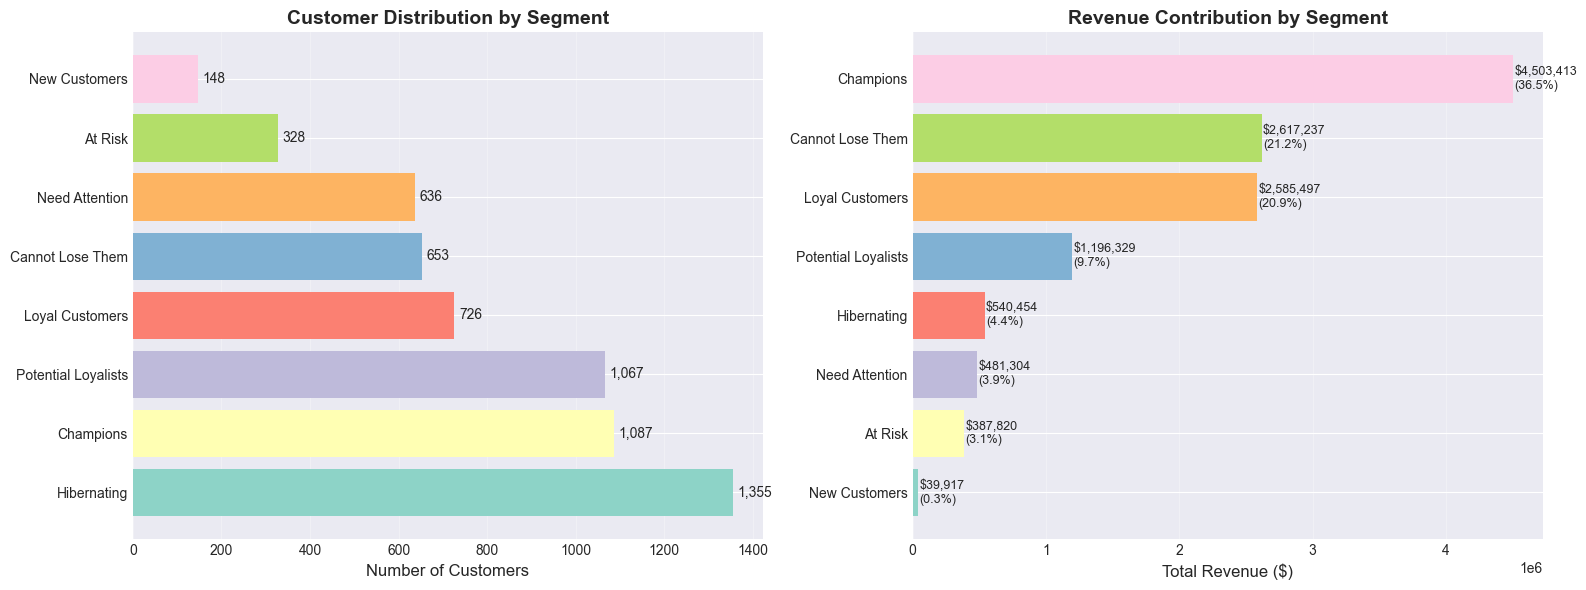

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

segment_counts = rfm['segment'].value_counts()
colors = plt.cm.Set3(range(len(segment_counts)))

axes[0].barh(segment_counts.index, segment_counts.values, color=colors)
axes[0].set_xlabel('Number of Customers', fontsize=12)
axes[0].set_title('Customer Distribution by Segment', fontsize=14, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)
for i, v in enumerate(segment_counts.values):
    axes[0].text(v + 10, i, f'{v:,}', va='center', fontsize=10)

segment_rev = rfm.groupby('segment')['monetary'].sum().sort_values(ascending=True)
axes[1].barh(segment_rev.index, segment_rev.values, color=colors)
axes[1].set_xlabel('Total Revenue ($)', fontsize=12)
axes[1].set_title('Revenue Contribution by Segment', fontsize=14, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)
for i, v in enumerate(segment_rev.values):
    pct = v / rfm['monetary'].sum() * 100
    axes[1].text(v + 10000, i, f'${v:,.0f}\n({pct:.1f}%)', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../visualizations/segment_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

## 12. Visualisation 2 - Pareto Chart

The classic Pareto chart: bars show each customer's individual revenue (ranked high to low), the red line is cumulative revenue percentage. The green dashed lines mark the 20% customer threshold and the actual cumulative revenue at that point.


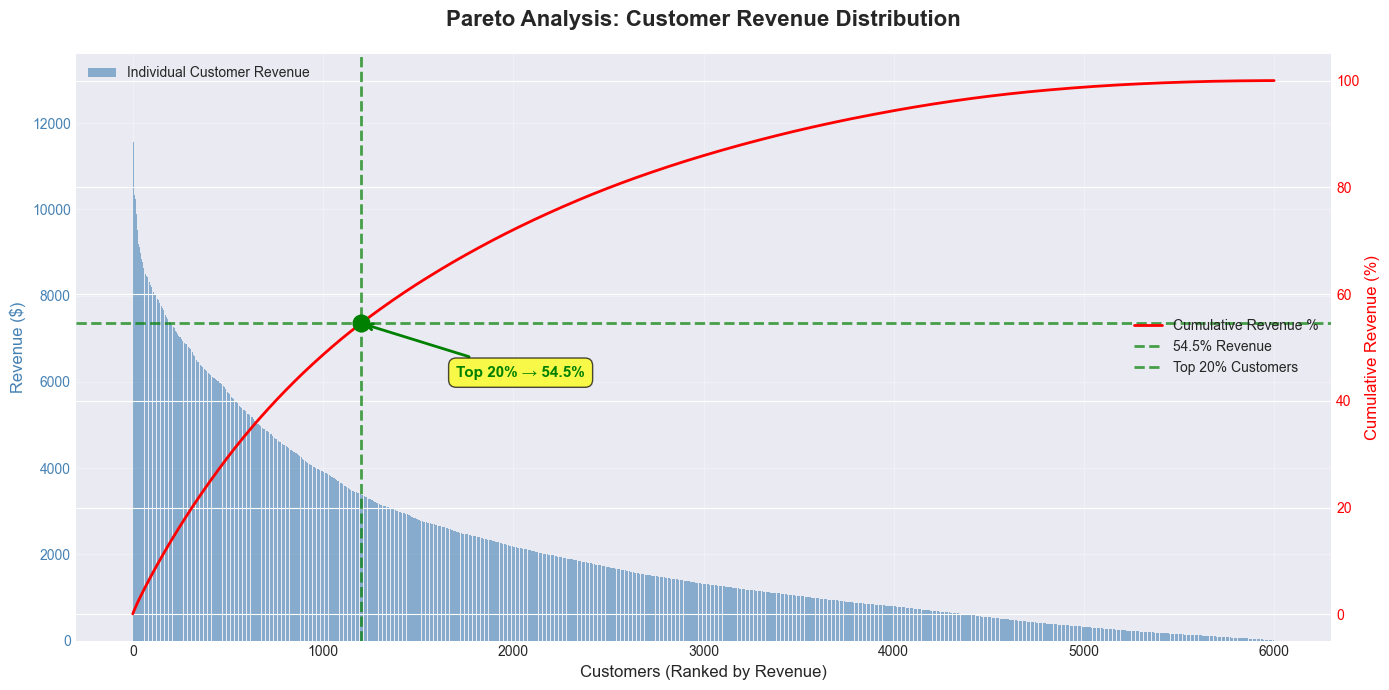


✅ KEY FINDING: Top 20% (1,200 customers) → 54.5% of revenue


In [13]:
fig, ax1 = plt.subplots(figsize=(14, 7))

ax1.bar(range(len(customer_revenue)), customer_revenue['monetary'],
        color='steelblue', alpha=0.6, label='Individual Customer Revenue')
ax1.set_xlabel('Customers (Ranked by Revenue)', fontsize=12)
ax1.set_ylabel('Revenue ($)', fontsize=12, color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.plot(customer_revenue.index, customer_revenue['cumulative_revenue_pct'],
         color='red', linewidth=2, label='Cumulative Revenue %')
ax2.set_ylabel('Cumulative Revenue (%)', fontsize=12, color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Dynamic reference lines
ax2.axhline(y=top_20_revenue_pct, color='green', linestyle='--', linewidth=2, alpha=0.7,
            label=f'{top_20_revenue_pct:.1f}% Revenue')
ax2.axvline(x=top_20_idx, color='green', linestyle='--', linewidth=2, alpha=0.7,
            label='Top 20% Customers')

ax2.plot(top_20_idx, top_20_revenue_pct, 'go', markersize=12)
ax2.annotate(f'Top 20% → {top_20_revenue_pct:.1f}%',
             xy=(top_20_idx, top_20_revenue_pct),
             xytext=(top_20_idx + 500, top_20_revenue_pct - 10),
             fontsize=11, fontweight='bold', color='green',
             bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7),
             arrowprops=dict(arrowstyle='->', color='green', lw=2))

ax1.set_title('Pareto Analysis: Customer Revenue Distribution', fontsize=16, fontweight='bold', pad=20)
ax1.legend(loc='upper left', fontsize=10)
ax2.legend(loc='center right', fontsize=10)
ax1.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../visualizations/pareto_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✅ KEY FINDING: Top 20% ({top_20_idx:,} customers) → {top_20_revenue_pct:.1f}% of revenue")

## 13. Visualisation 3 - RFM Heatmap

Each cell shows the **average monetary value** for customers at a given (Recency Score, Frequency Score) combination. The dark blue corner (top-right: high R, high F) represents our most valuable customers - Champions and high-value Loyals.


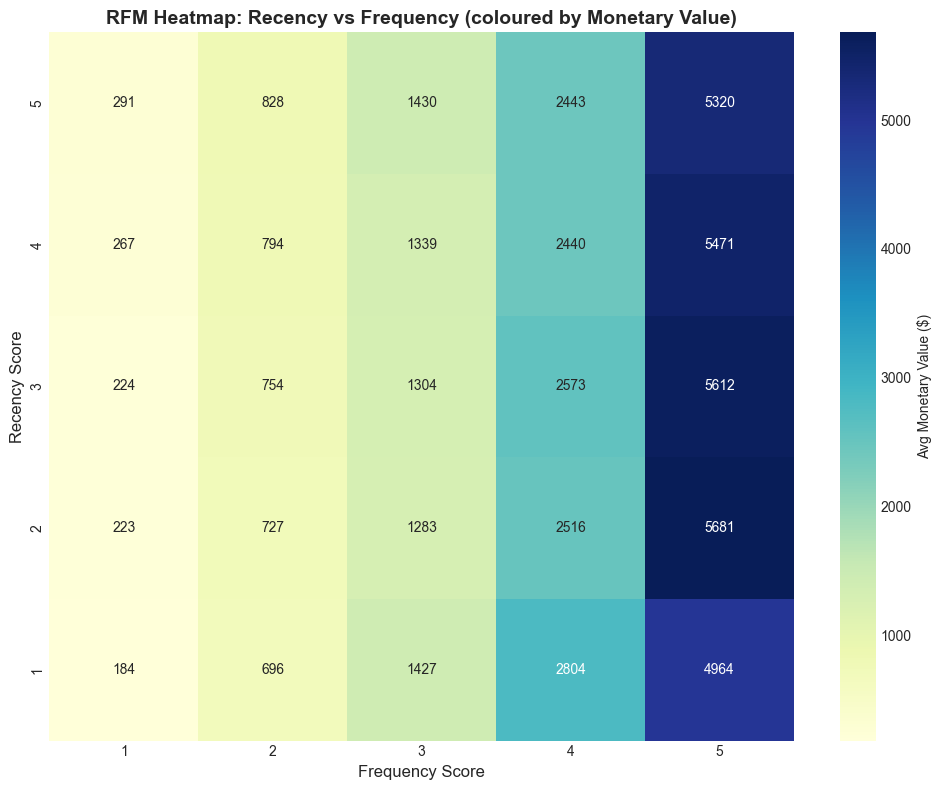

In [14]:
fig, ax = plt.subplots(figsize=(10, 8))

rfm_pivot = rfm.groupby(['r_score', 'f_score'])['monetary'].mean().unstack()
sns.heatmap(rfm_pivot, annot=True, fmt='.0f', cmap='YlGnBu',
            cbar_kws={'label': 'Avg Monetary Value ($)'})
ax.set_title('RFM Heatmap: Recency vs Frequency (coloured by Monetary Value)', fontsize=14, fontweight='bold')
ax.set_xlabel('Frequency Score', fontsize=12)
ax.set_ylabel('Recency Score', fontsize=12)

plt.tight_layout()
plt.savefig('../visualizations/rfm_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

## 14. Visualisation 4 - Cohort Retention Heatmap

Each row is a cohort (customers who made their first purchase in that month). Each column is how many months after first purchase. Green = high retention, red = low. We can see that month-1 retention stabilises around 40–55% for most cohorts - the critical window where onboarding efforts matter most.


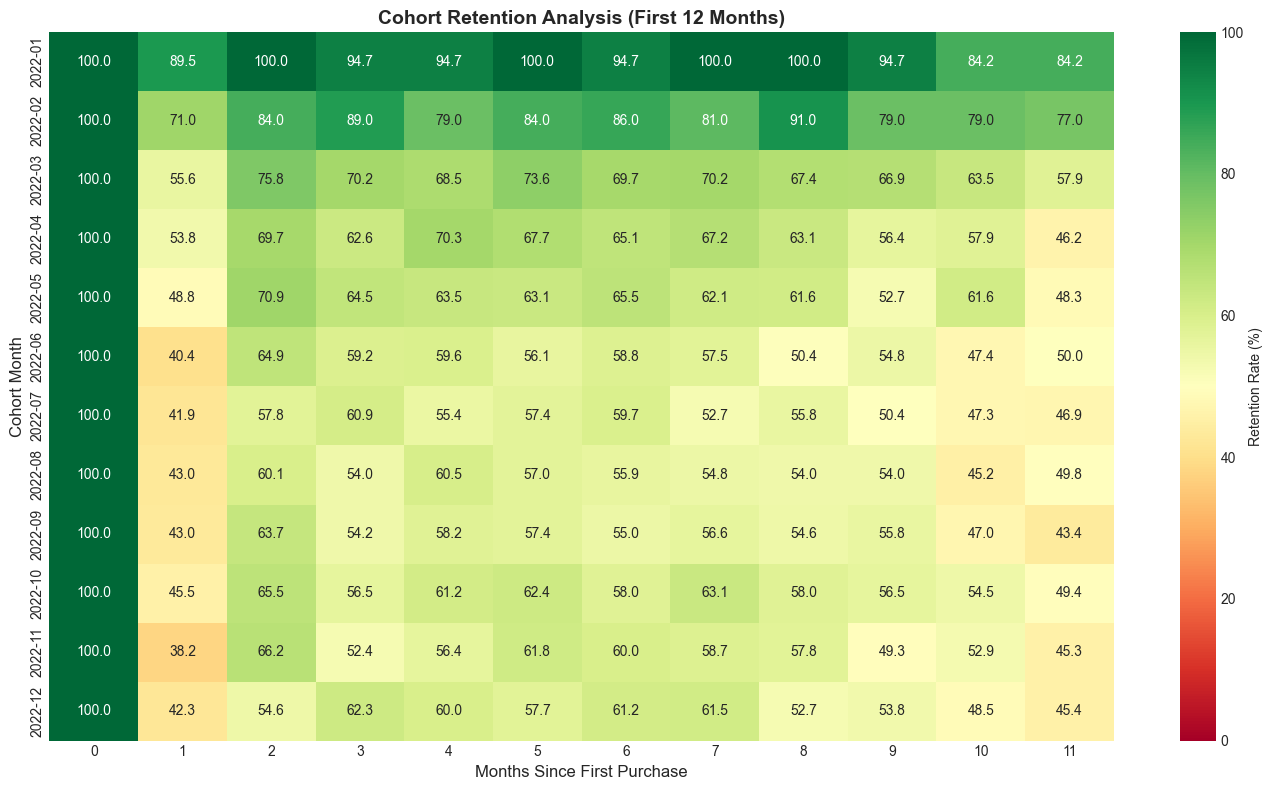

In [15]:
fig, ax = plt.subplots(figsize=(14, 8))

sns.heatmap(retention_matrix.iloc[:12, :12], annot=True, fmt='.1f', cmap='RdYlGn',
            vmin=0, vmax=100, cbar_kws={'label': 'Retention Rate (%)'})
ax.set_title('Cohort Retention Analysis (First 12 Months)', fontsize=14, fontweight='bold')
ax.set_xlabel('Months Since First Purchase', fontsize=12)
ax.set_ylabel('Cohort Month', fontsize=12)

plt.tight_layout()
plt.savefig('../visualizations/cohort_retention.png', dpi=300, bbox_inches='tight')
plt.show()

## 15. Business Recommendations

Each segment has a tailored strategy. The recommendations below are prioritised by revenue impact - protecting "Cannot Lose Them" and retaining "Champions" should be the top priorities.


In [16]:
print("=" * 70)
print("BUSINESS INSIGHTS & RECOMMENDATIONS")
print("=" * 70)

recommendations = {
    'Champions': {
        'characteristics': 'Best customers — high recency, frequency, and spend',
        'strategy':        'VIP programs, early access to new products, exclusive rewards',
        'expected_impact': 'Maintain loyalty and increase lifetime value'
    },
    'Cannot Lose Them': {
        'characteristics': 'High spenders who have not purchased recently — highest churn risk by revenue',
        'strategy':        'Urgent re-engagement, exclusive offers, dedicated account manager outreach',
        'expected_impact': 'Prevent significant revenue loss; recovering even 30% of these customers has outsized impact'
    },
    'Loyal Customers': {
        'characteristics': 'Frequent buyers with good monetary value',
        'strategy':        'Upsell premium products, referral programs, loyalty rewards',
        'expected_impact': 'Convert to Champions, increase average order value'
    },
    'At Risk': {
        'characteristics': 'Were frequent buyers but have not purchased recently',
        'strategy':        'Win-back campaigns, special discounts, "We miss you" emails',
        'expected_impact': 'Prevent churn, recover 15–25% of at-risk customers'
    },
    'New Customers': {
        'characteristics': 'Recent first-time buyers',
        'strategy':        'Onboarding emails, welcome discounts, build engagement early',
        'expected_impact': 'Convert to repeat buyers — the first 30 days are critical'
    },
    'Hibernating': {
        'characteristics': 'Low recency, low frequency — likely lost',
        'strategy':        'Low-cost re-engagement campaigns, survey for feedback',
        'expected_impact': 'Recover a small percentage; learnings inform future retention'
    }
}

for segment, details in recommendations.items():
    if segment in rfm['segment'].values:
        count   = len(rfm[rfm['segment'] == segment])
        revenue = rfm[rfm['segment'] == segment]['monetary'].sum()
        print(f"\n📊 {segment.upper()} ({count:,} customers | ${revenue:,.0f} revenue)")
        print(f"   Characteristics: {details['characteristics']}")
        print(f"   💡 Strategy:     {details['strategy']}")
        print(f"   🎯 Impact:       {details['expected_impact']}")

BUSINESS INSIGHTS & RECOMMENDATIONS

📊 CHAMPIONS (1,087 customers | $4,503,413 revenue)
   Characteristics: Best customers — high recency, frequency, and spend
   💡 Strategy:     VIP programs, early access to new products, exclusive rewards
   🎯 Impact:       Maintain loyalty and increase lifetime value

📊 CANNOT LOSE THEM (653 customers | $2,617,237 revenue)
   Characteristics: High spenders who have not purchased recently — highest churn risk by revenue
   💡 Strategy:     Urgent re-engagement, exclusive offers, dedicated account manager outreach
   🎯 Impact:       Prevent significant revenue loss; recovering even 30% of these customers has outsized impact

📊 LOYAL CUSTOMERS (726 customers | $2,585,497 revenue)
   Characteristics: Frequent buyers with good monetary value
   💡 Strategy:     Upsell premium products, referral programs, loyalty rewards
   🎯 Impact:       Convert to Champions, increase average order value

📊 AT RISK (328 customers | $387,820 revenue)
   Characteristics: We

## 16. Key Metrics Summary

A final recap of the most important numbers from this analysis.


In [17]:
print("\n" + "=" * 70)
print("FINAL SUMMARY: KEY METRICS")
print("=" * 70)

print(f"\n📈 OVERALL PERFORMANCE:")
print(f"   • Total Revenue:          ${total_revenue:,.2f}")
print(f"   • Total Customers:        {unique_customers:,}")
print(f"   • Total Transactions:     {total_transactions:,}")
print(f"   • Avg Transaction Value:  ${avg_transaction:.2f}")

print(f"\n🎯 PARETO INSIGHT:")
print(f"   • Top 20% customers ({top_20_idx:,}): {top_20_revenue_pct:.1f}% of revenue")
print(f"   • Focus retention efforts on these high-value customers")

print(f"\n👥 SEGMENT HIGHLIGHTS:")
champions      = len(rfm[rfm['segment'] == 'Champions'])
cannot_lose    = len(rfm[rfm['segment'] == 'Cannot Lose Them'])
at_risk        = len(rfm[rfm['segment'] == 'At Risk'])
print(f"   • Champions:        {champions:,} customers ({champions/len(rfm)*100:.1f}%)")
print(f"   • Cannot Lose Them: {cannot_lose:,} customers ({cannot_lose/len(rfm)*100:.1f}%) — highest-priority retention")
print(f"   • At Risk:          {at_risk:,} customers ({at_risk/len(rfm)*100:.1f}%)")

print(f"\n💰 CLV INSIGHT:")
avg_clv_champ = rfm[rfm['segment'] == 'Champions']['estimated_clv'].mean()
avg_clv_all   = rfm['estimated_clv'].mean()
print(f"   • Avg CLV (Champions):  ${avg_clv_champ:,.2f}")
print(f"   • Avg CLV (All):        ${avg_clv_all:,.2f}")
print(f"   • Champion CLV is {avg_clv_champ/avg_clv_all:.1f}× the overall average")

print("\n" + "=" * 70)
print("✅ ANALYSIS COMPLETE")
print("=" * 70)

# Save enriched RFM data
rfm.to_csv('../data/customer_rfm_segments.csv', index=False)
print("\n📁 RFM analysis saved to: data/customer_rfm_segments.csv")


FINAL SUMMARY: KEY METRICS

📈 OVERALL PERFORMANCE:
   • Total Revenue:          $12,351,971.28
   • Total Customers:        6,000
   • Total Transactions:     67,212
   • Avg Transaction Value:  $183.78

🎯 PARETO INSIGHT:
   • Top 20% customers (1,200): 54.5% of revenue
   • Focus retention efforts on these high-value customers

👥 SEGMENT HIGHLIGHTS:
   • Champions:        1,087 customers (18.1%)
   • Cannot Lose Them: 653 customers (10.9%) — highest-priority retention
   • At Risk:          328 customers (5.5%)

💰 CLV INSIGHT:
   • Avg CLV (Champions):  $9,340.32
   • Avg CLV (All):        $5,594.61
   • Champion CLV is 1.7× the overall average

✅ ANALYSIS COMPLETE

📁 RFM analysis saved to: data/customer_rfm_segments.csv
